In [7]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [8]:
df = pd.read_csv('train.csv')

In [9]:
df.head()

,id,qid1,qid2,question1,question2,is_duplicate
0,0,1,2,What is the step by step guide to invest in sh...,What is the step by step guide to invest in sh...,0
1,1,3,4,What is the story of Kohinoor (Koh-i-Noor) Dia...,What would happen if the Indian government sto...,0
2,2,5,6,How can I increase the speed of my internet co...,How can Internet speed be increased by hacking...,0
3,3,7,8,Why am I mentally very lonely? How can I solve...,Find the remainder when [math]23^{24}[/math] i...,0
4,4,9,10,"Which one dissolve in water quikly sugar, salt...",Which fish would survive in salt water?,0


In [10]:
new_df= df.sample(50000)

In [11]:
new_df.isnull().sum()

id              0
qid1            0
qid2            0
question1       0
question2       0
is_duplicate    0
dtype: int64

In [12]:
new_df.duplicated().sum()

0

In [13]:
new_df['q1_length']= new_df['question1'].str.len()
new_df['q2_length']= new_df['question2'].str.len()

In [14]:
new_df.head()

,id,qid1,qid2,question1,question2,is_duplicate,q1_length,q2_length
280161,280161,399698,399699,Subject line for release in project?,What is three dimensional printing?,0,36,35
175420,175420,270099,270100,What does it mean when I catch a guy looking a...,What does it mean when a boy is always looking...,1,70,64
206131,206131,309468,309469,How can I become perfect?,How can I become perfect in everything?,1,25,39
291074,291074,412438,412439,What are some causes of thoracolumbar fascia p...,What are the causes of thoracolumbar fascia pain?,1,50,49
343248,343248,202329,471340,What are examples of cultural bias?,How does cultural bias and gender bias differ?,0,35,46


In [15]:
new_df["q1_num_word"]= new_df['question1'].apply(lambda row: len(row.split(" ")))
new_df["q2_num_word"]= new_df['question2'].apply(lambda row: len(row.split(" ")))

In [16]:
new_df.head()

,id,qid1,qid2,question1,question2,is_duplicate,q1_length,q2_length,q1_num_word,q2_num_word
280161,280161,399698,399699,Subject line for release in project?,What is three dimensional printing?,0,36,35,6,5
175420,175420,270099,270100,What does it mean when I catch a guy looking a...,What does it mean when a boy is always looking...,1,70,64,16,14
206131,206131,309468,309469,How can I become perfect?,How can I become perfect in everything?,1,25,39,5,7
291074,291074,412438,412439,What are some causes of thoracolumbar fascia p...,What are the causes of thoracolumbar fascia pain?,1,50,49,8,8
343248,343248,202329,471340,What are examples of cultural bias?,How does cultural bias and gender bias differ?,0,35,46,6,8


In [17]:
new_df['common_words'] = new_df.apply(
    lambda row: len(set(row['question1'].lower().split())
                    & set(row['question2'].lower().split())),
    axis=1
)

In [18]:
new_df.head()

,id,qid1,qid2,question1,question2,is_duplicate,q1_length,q2_length,q1_num_word,q2_num_word,common_words
280161,280161,399698,399699,Subject line for release in project?,What is three dimensional printing?,0,36,35,6,5,0
175420,175420,270099,270100,What does it mean when I catch a guy looking a...,What does it mean when a boy is always looking...,1,70,64,16,14,11
206131,206131,309468,309469,How can I become perfect?,How can I become perfect in everything?,1,25,39,5,7,4
291074,291074,412438,412439,What are some causes of thoracolumbar fascia p...,What are the causes of thoracolumbar fascia pain?,1,50,49,8,8,7
343248,343248,202329,471340,What are examples of cultural bias?,How does cultural bias and gender bias differ?,0,35,46,6,8,1


In [19]:
def total_words(row):
    w1 = set(map(lambda word: word.lower().strip(),
             row['question1'].split(" ")))
    w2 = set(map(lambda word: word.lower().strip(),
             row['question2'].split(" ")))
    return (len(w1) + len(w2))

In [20]:
new_df['word_total'] = new_df.apply(total_words, axis=1)
new_df.head()

,id,qid1,qid2,question1,question2,is_duplicate,q1_length,q2_length,q1_num_word,q2_num_word,common_words,word_total
280161,280161,399698,399699,Subject line for release in project?,What is three dimensional printing?,0,36,35,6,5,0,11
175420,175420,270099,270100,What does it mean when I catch a guy looking a...,What does it mean when a boy is always looking...,1,70,64,16,14,11,30
206131,206131,309468,309469,How can I become perfect?,How can I become perfect in everything?,1,25,39,5,7,4,12
291074,291074,412438,412439,What are some causes of thoracolumbar fascia p...,What are the causes of thoracolumbar fascia pain?,1,50,49,8,8,7,16
343248,343248,202329,471340,What are examples of cultural bias?,How does cultural bias and gender bias differ?,0,35,46,6,8,1,13


In [21]:
new_df['word_share'] = round(new_df['common_words']/new_df['word_total'], 2)
new_df.head()

,id,qid1,qid2,question1,question2,is_duplicate,q1_length,q2_length,q1_num_word,q2_num_word,common_words,word_total,word_share
280161,280161,399698,399699,Subject line for release in project?,What is three dimensional printing?,0,36,35,6,5,0,11,0.00
175420,175420,270099,270100,What does it mean when I catch a guy looking a...,What does it mean when a boy is always looking...,1,70,64,16,14,11,30,0.37
206131,206131,309468,309469,How can I become perfect?,How can I become perfect in everything?,1,25,39,5,7,4,12,0.33
291074,291074,412438,412439,What are some causes of thoracolumbar fascia p...,What are the causes of thoracolumbar fascia pain?,1,50,49,8,8,7,16,0.44
343248,343248,202329,471340,What are examples of cultural bias?,How does cultural bias and gender bias differ?,0,35,46,6,8,1,13,0.08


In [22]:
%store new_df

Stored 'new_df' (DataFrame)


C:\Users\Acer\AppData\Roaming\Python\Python310\site-packages\IPython\extensions\storemagic.py:229: UserWarning: This is now an optional IPython functionality, setting autorestore/new_df requires you to install the `pickleshare` library.
  db[ 'autorestore/' + arg ] = obj


minimum characters 1
maximum characters 430
average num of characters 59


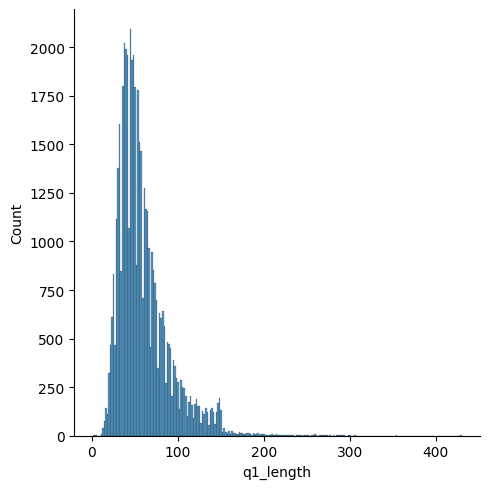

In [23]:
# Analysis of features
sns.displot(new_df['q1_length'])
print('minimum characters', new_df['q1_length'].min())
print('maximum characters', new_df['q1_length'].max())
print('average num of characters', int(new_df['q1_length'].mean()))

minimum characters 8
maximum characters 1169
average num of characters 60


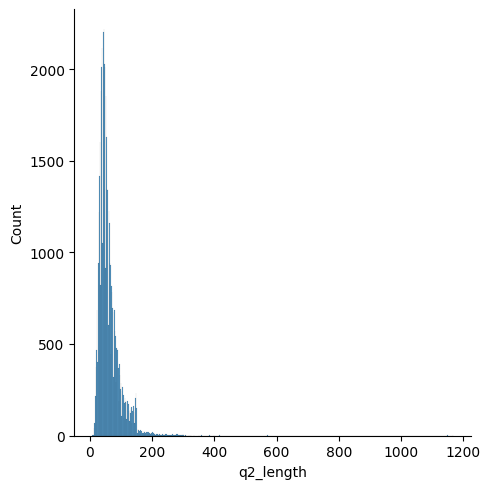

In [25]:
sns.displot(new_df['q2_length'])
print('minimum characters', new_df['q2_length'].min())
print('maximum characters', new_df['q2_length'].max())
print('average num of characters', int(new_df['q2_length'].mean()))

minimum words 1
maximum words 81
average num of words 10


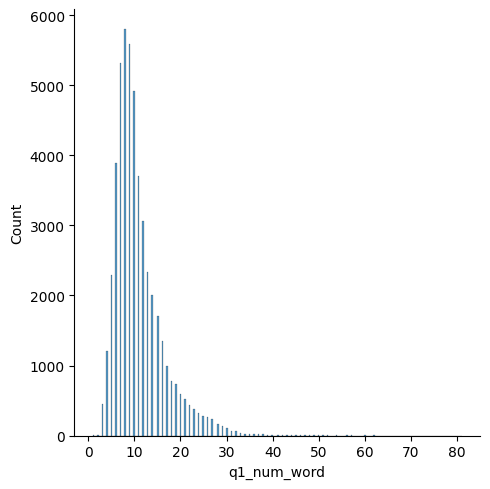

In [27]:
sns.displot(new_df['q1_num_word'])
print('minimum words', new_df['q1_num_word'].min())
print('maximum words', new_df['q1_num_word'].max())
print('average num of words', int(new_df['q1_num_word'].mean()))

minimum words 1
maximum words 237
average num of words 11


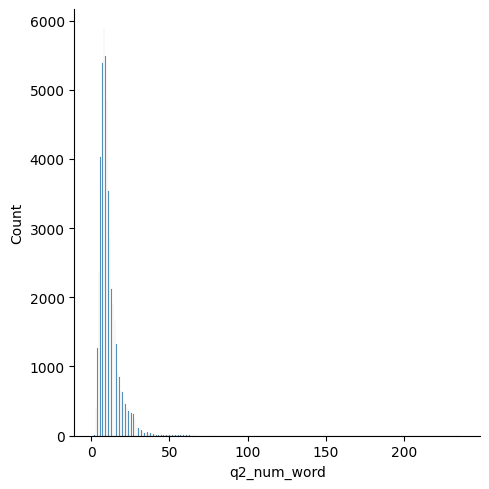

In [28]:
sns.displot(new_df['q2_num_word'])
print('minimum words', new_df['q2_num_word'].min())
print('maximum words', new_df['q2_num_word'].max())
print('average num of words', int(new_df['q2_num_word'].mean()))

C:\Users\Acer\AppData\Local\Temp\ipykernel_125208\458829151.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(new_df[new_df['is_duplicate'] == 0]
C:\Users\Acer\AppData\Local\Temp\ipykernel_125208\458829151.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(new_df[new_df['is_duplicate'] == 1]


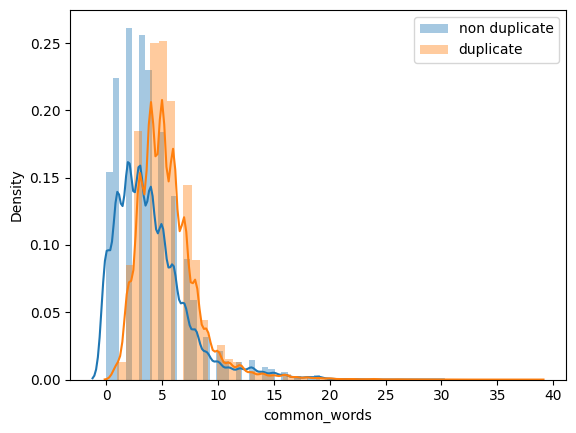

In [30]:
# common words
sns.distplot(new_df[new_df['is_duplicate'] == 0]
             ['common_words'], label='non duplicate')
sns.distplot(new_df[new_df['is_duplicate'] == 1]
             ['common_words'], label='duplicate')
plt.legend()
plt.show()

C:\Users\Acer\AppData\Local\Temp\ipykernel_125208\3585941105.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(new_df[new_df['is_duplicate'] == 0]
C:\Users\Acer\AppData\Local\Temp\ipykernel_125208\3585941105.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(new_df[new_df['is_duplicate'] == 1

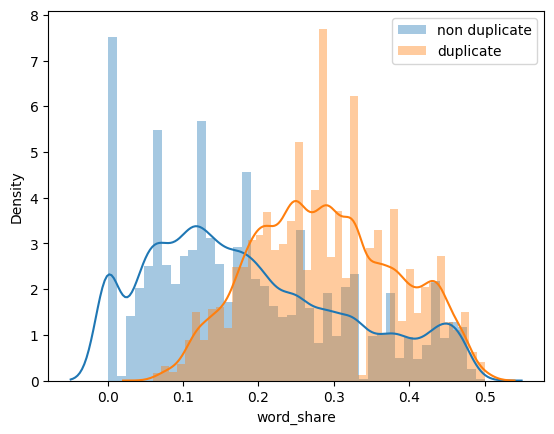

In [31]:
# word share
sns.distplot(new_df[new_df['is_duplicate'] == 0]
             ['word_share'], label='non duplicate')
sns.distplot(new_df[new_df['is_duplicate'] == 1]
             ['word_share'], label='duplicate')
plt.legend()
plt.show()

In [32]:
ques_df= new_df[['question1', 'question2']]

In [35]:
final_df = new_df[['id',	'qid1',	'qid2',	'q1_length', 'q2_length','q1_num_word',	'q2_num_word',	'common_words',	'word_total'	,'word_share' , 'is_duplicate']]

In [36]:
final_df.head()

,id,qid1,qid2,q1_length,q2_length,q1_num_word,q2_num_word,common_words,word_total,word_share,is_duplicate
280161,280161,399698,399699,36,35,6,5,0,11,0.00,0
175420,175420,270099,270100,70,64,16,14,11,30,0.37,1
206131,206131,309468,309469,25,39,5,7,4,12,0.33,1
291074,291074,412438,412439,50,49,8,8,7,16,0.44,1
343248,343248,202329,471340,35,46,6,8,1,13,0.08,0


In [37]:
ques_df.head()

,question1,question2
280161,Subject line for release in project?,What is three dimensional printing?
175420,What does it mean when I catch a guy looking a...,What does it mean when a boy is always looking...
206131,How can I become perfect?,How can I become perfect in everything?
291074,What are some causes of thoracolumbar fascia p...,What are the causes of thoracolumbar fascia pain?
343248,What are examples of cultural bias?,How does cultural bias and gender bias differ?


In [38]:
question= list(ques_df['question1']) + list(ques_df['question2'])

In [40]:
from sklearn.feature_extraction.text import CountVectorizer

cv= CountVectorizer(max_features= 5000)
q1_arr, q2_arr = np.vsplit(cv.fit_transform(question).toarray(), 2)

In [42]:
q1_arr.shape

(50000, 5000)

In [44]:
temp_df1 = pd.DataFrame(q1_arr, index=ques_df.index)
temp_df2 = pd.DataFrame(q2_arr, index=ques_df.index)
temp_df = pd.concat([temp_df1, temp_df2], axis=1)

In [45]:
temp_df.head()

,0,1,2,3,4,5,6,7,8,9,...,4990,4991,4992,4993,4994,4995,4996,4997,4998,4999
280161,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
175420,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
206131,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
291074,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
343248,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [49]:
new_final_df= pd.concat([temp_df, final_df], axis= 1)

In [50]:
new_final_df.head()

,0,1,2,3,4,5,6,7,8,9,...,qid1,qid2,q1_length,q2_length,q1_num_word,q2_num_word,common_words,word_total,word_share,is_duplicate
280161,0,0,0,0,0,0,0,0,0,0,...,399698,399699,36,35,6,5,0,11,0.00,0
175420,0,0,0,0,0,0,0,0,0,0,...,270099,270100,70,64,16,14,11,30,0.37,1
206131,0,0,0,0,0,0,0,0,0,0,...,309468,309469,25,39,5,7,4,12,0.33,1
291074,0,0,0,0,0,0,0,0,0,0,...,412438,412439,50,49,8,8,7,16,0.44,1
343248,0,0,0,0,0,0,0,0,0,0,...,202329,471340,35,46,6,8,1,13,0.08,0


In [51]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test= train_test_split(new_final_df.iloc[:, :-1], new_final_df.iloc[:, -1], test_size= 0.2, random_state= 2)

In [58]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# ensure all column names are strings to avoid mixed-type feature name error
x_train.columns = x_train.columns.astype(str)
x_test.columns = x_test.columns.astype(str)

lr = LogisticRegression()
lr.fit(x_train, y_train)

y_pred = lr.predict(x_test)

c:\Users\Acer\anaconda3\envs\py310\lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [59]:
accuracy_score(y_test, y_pred)

0.7201

In [ ]:
from sklearn.ensemble import RandomForestClassifier
rf= RandomForestClassifier()
rf.fit(x_train, y_train)
y_pred= rf.predict(x_test)

In [61]:
accuracy_score(y_test, y_pred)

0.783